In [ ]:
import pandas as pd
from transformers import BertTokenizer
from transformers import BertForSequenceClassification
from transformers import Trainer, TrainingArguments
import torch
from datasets import Dataset


In [ ]:
df = pd.read_csv(r'/content/classified_tweets.csv')

In [ ]:
df

,Unnamed: 0,text,emotion
0,0,10 Years Ago Welling United 0-1 Aldershot Town...,happiness
1,1,Thank you Coach Horton for a wonderful visit t...,happiness
2,2,"Remember years ago, softball used to be that w...",happiness
3,3,KAMIL SEMENIUK The Italian league champion wil...,neutral
4,4,Nebraska beach volleyball earned a dominant 5-...,happiness
...,...,...,...
8706,8706,O M G. Beach Day. Volleyball. Steve you beat H...,happiness
8707,8707,Congratulations to alumnus Tomas Sorra '17 on ...,neutral
8708,8708,This one's for the women who built it. On Marc...,happiness
8709,8709,On Impact Promotions & Media Will Be Live In T...,neutral


In [ ]:

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

dataset = Dataset.from_pandas(df)

dataset = dataset.map(tokenize, batched=True)

dataset = dataset.train_test_split(test_size=0.2)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/8711 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer)

In [ ]:

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=7
)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    eval_strategy="epoch"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    data_collator=data_collator
)
trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ValueError: The model did not return a loss from the inputs, only the following keys: logits. For reference, the inputs it received are input_ids,token_type_ids,attention_mask.

In [ ]:
# pip install pandas scikit-learn transformers datasets torch
## 📦 2. Импорт библиотек
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
## 📊 3. Загрузка и подготовка данных

In [ ]:
df = pd.read_csv(r'/content/classified_tweets.csv')
df_bert = df[['text', 'emotion']].copy()
# Загрузи свой датасет
# df = pd.read_csv("your_dataset.csv")  # columns: text, emotion

# Кодируем метки
label_encoder = LabelEncoder()
df_bert["label"] = label_encoder.fit_transform(df_bert["emotion"])

num_labels = len(label_encoder.classes_)
print(label_encoder.classes_)
## 4. Разделение на train / validation
train_df, val_df = train_test_split(
    df_bert,
    test_size=0.1,
    stratify=df_bert["label"],
    random_state=42
)

['anger' 'disgust' 'fear' 'happiness' 'neutral' 'sadness' 'surprise']


In [ ]:
 ## 5. Конвертация в HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
val_dataset = Dataset.from_pandas(val_df[["text", "label"]])

In [ ]:
## 6. Токенизация
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/7839 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

In [ ]:
## 7. Модель BERT
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:

## 8. Метрики оценки
def compute_metrics(pred):
    logits, labels = pred
    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [ ]:

## 9. Настройки обучения
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,

    eval_strategy="epoch",   # иногда evaluation_strategy, но у тебя работает eval_strategy
    save_strategy="epoch",

    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
## 10.1 Model
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=7
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:

# !pip install evaluate

In [ ]:
## 10.2 Metrics (F1 + Accuracy)
# pip install evaluate
import numpy as np
import evaluate

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "f1": f1.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    }

In [ ]:

val_dataset

Dataset({
    features: ['text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 872
})

In [ ]:
# 10.3 Trainer
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


In [ ]:

# pip install numpy==1.26.4
import numpy as np
print(np.__version__)
import torch

2.0.2


In [ ]:

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
df.emotion.value_counts()
import torch
print(torch.cuda.is_available())

True
Tesla T4
True


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.372472,0.915138,0.900414
2,0.515789,0.277121,0.941514,0.937560
3,0.263071,0.286530,0.942661,0.939628
4,0.179886,0.289401,0.944954,0.942520


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1960, training_loss=0.27673632758004324, metrics={'train_runtime': 893.2699, 'train_samples_per_second': 35.102, 'train_steps_per_second': 2.194, 'total_flos': 2062620155980800.0, 'train_loss': 0.27673632758004324, 'epoch': 4.0})

In [ ]:
# 📈 3. Предсказания на тесте
predictions = trainer.predict(dataset["test"])


In [ ]:
print(dataset["test"].column_names)

['Unnamed: 0', 'text', 'emotion', 'input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
dataset['test']

Dataset({
    features: ['Unnamed: 0', 'text', 'emotion', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 1743
})

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

dataset = dataset.map(lambda x: {
    "labels": le.fit_transform([x["emotion"]])[0]
})

Map:   0%|          | 0/6968 [00:00<?, ? examples/s]

Map:   0%|          | 0/1743 [00:00<?, ? examples/s]

In [ ]:

# dataset = dataset.rename_column("emotion", "labels")

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["labels"] = le.fit_transform(df["emotion"])


from datasets import Dataset

dataset = Dataset.from_pandas(df)

In [ ]:
dataset = dataset.train_test_split(test_size=0.2)

In [ ]:
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding=True)

dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/6968 [00:00<?, ? examples/s]

Map:   0%|          | 0/1743 [00:00<?, ? examples/s]

In [ ]:
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [ ]:
dataset['test']['labels']

Column([tensor(3), tensor(3), tensor(4), tensor(4), tensor(4)])

In [ ]:
print(dataset[0])

KeyError: "Invalid key: 0. Please first select a split. For example: `my_dataset_dictionary['train'][0]`. Available splits: ['test', 'train']"

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
predictions = trainer.predict(dataset["test"])

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82        51
           1       0.00      0.00      0.00         1
           2       0.75      0.50      0.60         6
           3       0.99      0.95      0.97       622
           4       0.96      1.00      0.98       996
           5       0.92      0.94      0.93        65
           6       0.00      0.00      0.00         2

    accuracy                           0.97      1743
   macro avg       0.64      0.59      0.61      1743
weighted avg       0.97      0.97      0.97      1743



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


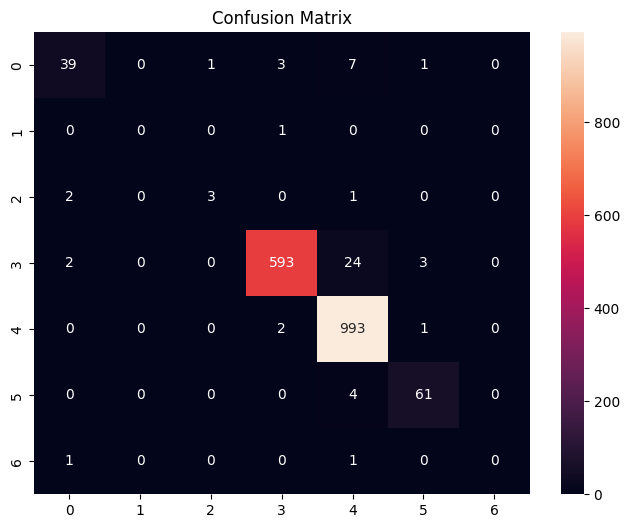

In [ ]:
# 3.1. Матрица ошибок (обязательно)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import torch

def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # 🔥 ВАЖНО — отправляем на тот же device
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred_id = torch.argmax(outputs.logits, dim=1).item()
    return label_names[pred_id]

In [ ]:
predict("What a fantastic match!!!")

'sadness'

# Сохраняем модель

In [ ]:
trainer.save_model("my_emotion_model")
tokenizer.save_pretrained("my_emotion_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('my_emotion_model/tokenizer_config.json', 'my_emotion_model/tokenizer.json')

In [ ]:
# Как загрузить модель потом
from transformers import BertTokenizer, BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained("my_emotion_model")
tokenizer = BertTokenizer.from_pretrained("my_emotion_model")

In [ ]:
## Используем послу загрузки
import torch

label_names = ["neutral", "happiness", "anger", "disgust", "sadness", "surprise", "fear"]

def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred_id = torch.argmax(outputs.logits, dim=1).item()
    return label_names[pred_id]